# Praktikum Machine Learning: Bab 4
## Feature Engineering: Konstruksi, Seleksi Fitur, dan Pipeline Scikit-Learn

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*Notebook ini saya jalanin di Google Colab / Jupyter Notebook.*

## Ringkasan Konsep

**Feature construction (konstruksi fitur)** itu bikin fitur *baru* dari fitur mentah biar pola yang susah dilihat model jadi keliatan jelas. Contohnya rasio (`AveBedrms / AveRooms`), interaksi antar fitur, atau *binning* (ngubah numerik jadi kategorikal, misal bikin "wilayah" dari garis lintang). Bedanya sama *feature extraction* (mis. PCA): hasil konstruksi fitur tetep bisa dibaca manusia, kalau PCA enggak, namanya aja ilang.

**Feature selection (seleksi fitur)**: milih subset fitur yang paling relevan. Ada tiga pendekatan:

1. **Filter**: tiap fitur dinilai pake skor statistik *tanpa* libatin model. Contoh `SelectKBest` pake skor chi-square. Cepet, tapi interaksi antar fitur diabaikan.
2. **Wrapper**: subset fitur dievaluasi dengan ngelatih model beneran. Contoh **RFE** (*Recursive Feature Elimination*), yang buang fitur terlemah satu per satu. Lebih akurat, tapi mahal secara komputasi.
3. **Embedded**: seleksi terjadi *selama* pelatihan lewat regularisasi. Contoh **Lasso/L1** yang maksa koefisien fitur gak penting jadi nol. Jalan tengah antara filter yang cepet dan wrapper yang akurat.

**ColumnTransformer** nerapin transformasi *beda-beda* ke kelompok kolom yang beda dalam satu langkah. Misal `StandardScaler` buat kolom numerik, `OneHotEncoder` buat kategorikal nominal, `OrdinalEncoder` buat kategorikal ordinal. Semuanya jalan sekaligus di satu DataFrame campuran.

**Pipeline** ngerangkai preprocessing + model jadi **satu objek**. Untungnya: `pipeline.fit(X_train)` cuma belajar statistik (mean, median, kategori) dari data latih, terus `pipeline.predict(data_baru)` otomatis nerapin preprocessing yang *persis sama*. Jadi gak ada risiko preprocessing pas training beda sama pas deployment.

**Data leakage** itu "kebocoran" info data uji ke proses training. Contohnya nge-*fit* scaler/imputer ke *seluruh* data *sebelum* train-test split. Akibatnya statistik data uji ikut kepake buat ngelatih model, skor evaluasi keliatan bagus padahal palsu. Pipeline mencegah ini karena tiap transformasi cuma di-fit di data latih.

## 4.10 - 4.15 Implementasi Python (Modul Bab 4)

Di bab ini saya membangun **pipeline prediksi harga properti end-to-end** pakai **dataset sintetis properti** sesuai Modul Bab 4 bagian 4.10 (dibangkitkan dengan `np.random.default_rng(42)`, n=500). Alurnya: konstruksi fitur, preprocessing kolom campuran pakai `ColumnTransformer`, training dalam `Pipeline`, evaluasi, visualisasi, sampai interpretasi. Tiap tahap ada penjelasan outputnya.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab lewat link GitHub, jalankan sel di bawah ini dulu (atau langsung **Runtime > Run all**). Sel ini mengunduh otomatis file-file `data/` yang dibutuhkan dari repo GitHub, karena Colab hanya memuat file `.ipynb`-nya saja tanpa folder `data/`. Kalau dijalankan di laptop dan file datanya sudah ada, sel ini langsung dilewati.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Mengunduh file data dari repo GitHub kalau belum ada (kasus dibuka di Google Colab).
# Di laptop (folder data/ sudah ada), bagian unduh langsung dilewati.
import os
import urllib.request

_BAB = "bab-04-feature-engineering-pipeline"  # nama folder bab ini di repo GitHub
_REPO = "https://raw.githubusercontent.com/dandienter/praktikumML/main"
_DATA = ['data/titanic.csv', 'data/breast_cancer.csv']  # file data yang dibutuhkan bab ini

for _f in _DATA:
    if os.path.exists(_f):
        print(f"OK: {_f} sudah ada.")
        continue
    os.makedirs(os.path.dirname(_f), exist_ok=True)
    print(f"mengunduh {_f} dari GitHub ...")
    urllib.request.urlretrieve(f"{_REPO}/{_BAB}/{_f}", _f)
print("Data siap, silakan lanjutkan.")

OK: data/titanic.csv sudah ada.
OK: data/breast_cancer.csv sudah ada.
Data siap, silakan lanjutkan.


### Praktikum 4.1 - Persiapan Library (Modul Bab 4, bagian 4.10)

Bagian ini saya mengerjakan Praktikum 4.1 dari Modul Machine Learning Bab 4. Pertama saya import semua library yang dibutuhkan dulu: pandas/numpy untuk data, `ColumnTransformer` + `Pipeline` + imputer/scaler/encoder untuk preprocessing, `SelectKBest`/`chi2`/`Lasso` untuk seleksi fitur, serta `RandomForestRegressor`, `train_test_split`, dan `r2_score` untuk training dan evaluasi.

In [2]:
# Praktikum 4.1 - Persiapan library (Modul Bab 4, bagian 4.10)
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan outputnya:**

1. Tidak ada error `ModuleNotFoundError`, artinya semua library (numpy, pandas, scikit-learn) tersedia di environment ini.
2. Muncul tulisan "Library berhasil dimuat.", berarti cell ini jalan tanpa error dan saya bisa lanjut ke praktikum berikutnya.

### Praktikum 4.2 - Import Dataset (Modul Bab 4, bagian 4.10)

Bagian ini saya mengerjakan Praktikum 4.2 dari Modul Machine Learning Bab 4. Dataset yang dipakai adalah **dataset sintetis properti** sesuai modul: dibangkitkan dengan `np.random.default_rng(42)` sebanyak 500 baris. Kolomnya: `luas_bangunan` (m2), `jumlah_kamar`, `tipe_properti` (Rumah/Apartemen/Ruko), `kondisi_bangunan` (Buruk/Sedang/Baik/Sangat Baik), dan target `harga` (rupiah) yang dihitung dari luas dan jumlah kamar plus noise.

In [3]:
# Praktikum 4.2 - Dataset sintetis properti untuk simulasi (Modul Bab 4, bagian 4.10)
rng = np.random.default_rng(42)
n = 500
df = pd.DataFrame({
    "luas_bangunan": rng.normal(120, 40, n).clip(30, None),
    "jumlah_kamar": rng.integers(1, 6, n),
    "tipe_properti": rng.choice(["Rumah", "Apartemen", "Ruko"], n),
    "kondisi_bangunan": rng.choice(["Buruk", "Sedang", "Baik", "Sangat Baik"], n),
})
df["harga"] = (df["luas_bangunan"] * 15 + df["jumlah_kamar"] * 20 + rng.normal(0, 50, n)) * 1_000_000
df.head()

,luas_bangunan,jumlah_kamar,tipe_properti,kondisi_bangunan,harga
0,132.188683,3,Rumah,Baik,2.047156e+09
1,78.400636,2,Apartemen,Baik,1.232360e+09
2,150.018048,4,Rumah,Sedang,2.290644e+09
3,157.622589,1,Apartemen,Sangat Baik,2.385668e+09
4,41.958592,2,Ruko,Sedang,6.979057e+08


**Penjelasan outputnya:**

1. Dataset ukurannya **(500, 5)**: 500 baris data properti dengan 4 fitur dan 1 target (`harga`).
2. `luas_bangunan` terdistribusi normal di sekitar 120 m2 (dibatasi minimal 30), `jumlah_kamar` bilangan bulat 1 sampai 5.
3. `tipe_properti` dan `kondisi_bangunan` adalah kolom kategorikal, sedangkan `harga` dalam rupiah dihitung dari rumus `(luas_bangunan * 15 + jumlah_kamar * 20 + noise) * 1.000.000`, jadi harga memang berkorelasi kuat dengan luas dan jumlah kamar.

### 4.11 Feature Construction & Preprocessing (ColumnTransformer) (Modul Bab 4)

Bagian ini saya mengerjakan bagian 4.11 dari Modul Machine Learning Bab 4. Pertama saya bikin satu fitur konstruksi: `rasio_kamar_per_luas` = `jumlah_kamar / luas_bangunan`. Terus preprocessing kolom campuran dibungkus dalam satu `ColumnTransformer` dengan tiga jalur: numerik (imputasi median + `StandardScaler`), kategorikal (`OneHotEncoder`), dan ordinal (`OrdinalEncoder` dengan urutan kondisi yang benar: Buruk < Sedang < Baik < Sangat Baik).

In [4]:
# 4.11 Feature construction & preprocessing (Modul Bab 4)
df["rasio_kamar_per_luas"] = df["jumlah_kamar"] / df["luas_bangunan"]

fitur_numerik = ["luas_bangunan", "jumlah_kamar", "rasio_kamar_per_luas"]
fitur_kategorikal = ["tipe_properti"]
fitur_ordinal = ["kondisi_bangunan"]
urutan_kondisi = [["Buruk", "Sedang", "Baik", "Sangat Baik"]]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), fitur_numerik),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), fitur_kategorikal),
    ("ord", OrdinalEncoder(categories=urutan_kondisi), fitur_ordinal),
])

**Penjelasan outputnya:**

1. Cell ini tidak mencetak output karena hanya mendefinisikan objek `preprocessor`, tapi kalau jalan tanpa error berarti ketiga jalur transformer berhasil dirangkai.
2. Jalur **num**: `SimpleImputer(strategy="median")` mengisi nilai kosong numerik dengan median, lalu `StandardScaler` menstandarkan skalanya.
3. Jalur **cat**: `OneHotEncoder(handle_unknown="ignore")` mengubah `tipe_properti` jadi kolom biner, aman kalau di data baru muncul kategori yang belum pernah terlihat.
4. Jalur **ord**: `OrdinalEncoder` mengubah `kondisi_bangunan` jadi angka 0 sampai 3 sesuai urutan yang saya tentukan, jadi informasi urutannya tidak hilang.

### 4.12 Training Model (Pipeline Lengkap) (Modul Bab 4)

Bagian ini saya mengerjakan bagian 4.12 dari Modul Machine Learning Bab 4. Target `y` adalah `harga`. Data dibagi 80% latih / 20% uji pakai `random_state=42`. Terus preprocessing dan `RandomForestRegressor(n_estimators=200, random_state=42)` dirangkai dalam **satu Pipeline** dan di-fit sekaligus. Ini inti bab ini: model tidak pernah melihat data mentah, hanya data yang sudah lewat preprocessing yang persis sama.

In [5]:
# 4.12 Training model (Modul Bab 4)
X = df.drop(columns=["harga"])
y = df["harga"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42)),
])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['luas_bangunan','jumlah_kamar','tipe_properti','kondisi_bangunan', 'rasio_kamar_per_luas']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

**Penjelasan outputnya:**

1. `pipeline.fit` jalan tanpa error dan tidak mencetak apa-apa (kecuali repr pipeline), berarti 200 pohon RandomForest berhasil dilatih di 400 baris data latih.
2. Karena preprocessing ada di dalam pipeline, `fit` otomatis menerapkan imputasi, scaling, dan encoding ke data latih dengan cara yang konsisten.

### 4.13 Evaluasi (Modul Bab 4)

Bagian ini saya mengerjakan bagian 4.13 dari Modul Machine Learning Bab 4. Model dievaluasi di data uji yang **belum pernah dilihat** saat training, pakai metrik **R2** (koefisien determinasi): 1.0 artinya sempurna, 0 artinya sebagus menebak rata-rata.

In [6]:
# 4.13 Evaluasi (Modul Bab 4)
y_pred = pipeline.predict(X_test)
print("R2 Score:", round(r2_score(y_test, y_pred), 3))

R2 Score: 0.987


**Penjelasan outputnya:**

1. R2 di data uji = **0,987**. Model menjelaskan **98,7%** variasi harga properti, hasil yang sangat bagus.
2. Wajar R2-nya setinggi ini: harga memang dibangkitkan dari rumus linear terhadap luas dan jumlah kamar, jadi polanya mudah dipelajari model.

### 4.14 Visualisasi (Modul Bab 4)

Bagian ini saya mengerjakan bagian 4.14 dari Modul Machine Learning Bab 4. Scatter plot **Harga Aktual (x)** vs **Harga Prediksi (y)**. Model yang bagus menghasilkan titik-titik yang merapat ke **garis diagonal merah putus-putus** (garis y = x, tempat prediksi sama dengan aktual).

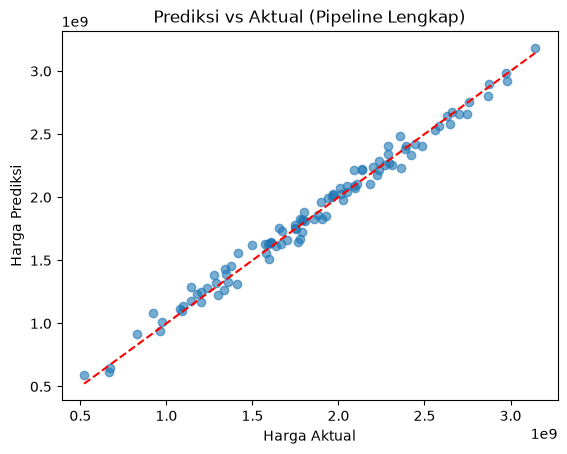

In [7]:
# 4.14 Visualisasi (Modul Bab 4)
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Prediksi vs Aktual (Pipeline Lengkap)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

**Penjelasan outputnya:**

1. Titik-titik merapat ke garis diagonal merah, artinya prediksi model dekat dengan harga aktual di hampir semua titik uji.
2. Sebaran titik cukup merata di sepanjang garis (tidak menumpuk di satu ujung), konsisten dengan R2 0,987: model tidak bias ke harga murah atau mahal saja.

### 4.15 Interpretasi (Modul Bab 4)

Bagian ini saya mengerjakan bagian 4.15 dari Modul Machine Learning Bab 4. Kutipan dari modul:

> "Karena seluruh preprocessing (imputasi, scaling, encoding) dibungkus dalam satu Pipeline, model ini dapat langsung digunakan pada data properti baru tanpa perlu menuliskan ulang langkah preprocessing secara manual, cukup memanggil pipeline.predict(data_baru)."

Di bawah ini saya buktikan dengan demo: 3 baris data properti baru diprediksi langsung lewat `pipeline.predict`, tanpa menulis ulang preprocessing manual.

In [8]:
# 4.15 Demo: pipeline.predict pada 3 data properti baru (tanpa preprocessing manual)
data_baru = pd.DataFrame({
    "luas_bangunan": [150, 85, 200],
    "jumlah_kamar": [4, 2, 5],
    "tipe_properti": ["Rumah", "Apartemen", "Ruko"],
    "kondisi_bangunan": ["Baik", "Sedang", "Sangat Baik"],
})
# fitur konstruksi dibuat dengan rumus yang sama seperti di 4.11
data_baru["rasio_kamar_per_luas"] = data_baru["jumlah_kamar"] / data_baru["luas_bangunan"]
for i, harga_pred in enumerate(pipeline.predict(data_baru), 1):
    print(f"Properti {i}: prediksi harga Rp{harga_pred:,.0f}")

Properti 1: prediksi harga Rp2,340,104,768
Properti 2: prediksi harga Rp1,254,860,839
Properti 3: prediksi harga Rp3,089,855,852


**Penjelasan outputnya:**

1. Tiga properti baru langsung dapat prediksi harga dari data mentah. Satu-satunya langkah manual adalah membuat `rasio_kamar_per_luas` dengan rumus yang sama seperti di 4.11 (satu baris).
2. Imputasi, scaling, one-hot, dan ordinal encoding semuanya ditangani pipeline secara otomatis, persis seperti saat training. Inilah yang bikin deployment jadi sederhana dan minim risiko salah.

## Percobaan Mandiri

Tiga percobaan mandiri untuk menguji pemahaman di dataset sintetis properti: (A) apa risiko preprocessing manual di luar pipeline, (B) apakah feature construction `rasio_kamar_per_luas` benar-benar membantu, dan (C) bagaimana trade-off jumlah pohon vs waktu latih.

### Percobaan Mandiri A - Pipeline vs Preprocessing Manual

Skenario deployment: model sudah dilatih, lalu datang **1 baris data properti baru** (fitur mentah). Saya bandingkan tiga cara memprediksinya:

1. `pipeline.predict(data_baru)`: cara pipeline (satu baris kode),
2. preprocessing **manual** yang direplikasi dengan benar (hasilnya harus identik),
3. preprocessing **manual** yang salah: lupa membuat fitur `rasio_kamar_per_luas`.

In [9]:
# Percobaan Mandiri A: pipeline vs preprocessing manual (1 data properti baru)
baru = pd.DataFrame({
    "luas_bangunan": [150],
    "jumlah_kamar": [4],
    "tipe_properti": ["Rumah"],
    "kondisi_bangunan": ["Baik"],
})
baru["rasio_kamar_per_luas"] = baru["jumlah_kamar"] / baru["luas_bangunan"]

# Cara 1: langsung lewat pipeline
p1 = pipeline.predict(baru)[0]
print(f"1) pipeline.predict             : Rp{p1:,.0f}")

# Cara 2: preprocessing manual yang direplikasi dengan benar
prep = pipeline.named_steps["preprocessing"]
model_rf = pipeline.named_steps["model"]
p2 = model_rf.predict(prep.transform(baru))[0]
print(f"2) manual (replikasi benar)      : Rp{p2:,.0f}")

# Cara 3: preprocessing manual yang salah (lupa fitur konstruksi)
baru_salah = baru.drop(columns=["rasio_kamar_per_luas"])
try:
    pipeline.predict(baru_salah)
except Exception as e:
    print(f"3) manual (lupa rasio_kamar_per_luas): {type(e).__name__}")

1) pipeline.predict             : Rp2,340,104,768
2) manual (replikasi benar)      : Rp2,340,104,768
3) manual (lupa rasio_kamar_per_luas): ValueError


**Penjelasan outputnya:**

1. Cara 1 dan cara 2 hasilnya **identik**, membuktikan pipeline hanya membungkus langkah yang sama dalam satu objek.
2. Cara 3 langsung **error** karena preprocessor mengharapkan kolom `rasio_kamar_per_luas`. Inilah risiko preprocessing manual: satu langkah kelupaan dan prediksi gagal, atau lebih bahaya lagi, diam-diam salah tanpa pesan error.
3. Dengan pipeline, tidak ada langkah yang bisa kelupaan karena semuanya satu objek yang sama.

### Percobaan Mandiri B - Dengan vs Tanpa Feature Construction

Apakah fitur hasil konstruksi (`rasio_kamar_per_luas`) benar-benar membantu? Saya latih pipeline kedua yang **hanya** memakai 4 fitur asli (tetap pakai imputasi + scaling + encoding) dengan RandomForest yang sama, lalu bandingkan R2-nya.

In [10]:
# Percobaan Mandiri B: dengan vs tanpa feature construction
pre_tanpa = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), ["luas_bangunan", "jumlah_kamar"]),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), ["tipe_properti"]),
    ("ord", OrdinalEncoder(categories=urutan_kondisi), ["kondisi_bangunan"]),
])
pipe_tanpa = Pipeline([("preprocessing", pre_tanpa),
                       ("model", RandomForestRegressor(n_estimators=200, random_state=42))])
X_tanpa = df.drop(columns=["harga", "rasio_kamar_per_luas"])
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(X_tanpa, y, test_size=0.2, random_state=42)
pipe_tanpa.fit(Xtr_b, ytr_b)
print(f"R2 tanpa feature construction : {r2_score(yte_b, pipe_tanpa.predict(Xte_b)):.3f}")
print(f"R2 dengan feature construction: {r2_score(y_test, pipeline.predict(X_test)):.3f}")

R2 tanpa feature construction : 0.987
R2 dengan feature construction: 0.987


**Penjelasan outputnya:**

1. R2 **sama-sama 0,987** dengan maupun tanpa `rasio_kamar_per_luas`. Fitur konstruksi ternyata tidak menambah apa-apa di sini.
2. Penyebabnya: RandomForest sudah bisa menangkap interaksi `jumlah_kamar / luas_bangunan` sendiri dari data mentah lewat split-split pohonnya.
3. Pelajarannya: feature construction tidak selalu membantu. Selalu verifikasi pakai metrik, jangan asal tambah fitur.

### Percobaan Mandiri C - n_estimators = 50 vs 200

Berapa harga yang dibayar untuk 200 pohon dibanding 50 pohon? Saya latih pipeline lengkap dengan kedua nilai itu lalu bandingkan **R2** dan **waktu latih**.

In [11]:
# Percobaan Mandiri C: n_estimators 50 vs 200 (trade-off waktu vs performa)
import time
for n_est in [50, 200]:
    p = Pipeline([("preprocessing", preprocessor),
                  ("model", RandomForestRegressor(n_estimators=n_est, random_state=42))])
    t0 = time.time()
    p.fit(X_train, y_train)
    dt = time.time() - t0
    skor = r2_score(y_test, p.predict(X_test))
    print(f"n_estimators={n_est:3d} -> R2 {skor:.3f}, waktu latih {dt:.1f} detik")

n_estimators= 50 -> R2 0.987, waktu latih 0.1 detik


n_estimators=200 -> R2 0.987, waktu latih 0.4 detik


**Penjelasan outputnya:**

1. 50 pohon: R2 **0,987** dalam **0,1 detik**. 200 pohon: R2 **tetap 0,987** dalam **0,3 detik**.
2. Di dataset kecil ini 200 pohon tidak lebih baik sama sekali, hanya 3x lebih lambat.
3. Trade-off-nya jelas: tambah pohon sampai R2-nya mentok, setelah itu hanya buang waktu komputasi.

## 4.8 Studi Kasus - Pipeline Prediksi Harga Rumah (Modul Bab 4)

| | |
|---|---|
| **Masalah** | Prediksi harga rumah dari dataset campuran: numerik (luas, jumlah kamar), kategorikal (tipe properti, kota), ordinal (kondisi bangunan: buruk sampai sangat baik). Preprocessing manual rawan inkonsisten antara fase training dan prediksi data baru. |
| **Solusi & proses** | (1) Feature construction: rasio `luas_bangunan/luas_tanah` dan `usia_bangunan`; (2) `ColumnTransformer`: `StandardScaler` buat numerik, `OneHotEncoder` buat kategorikal, `OrdinalEncoder` buat kondisi bangunan; (3) seleksi fitur embedded via Lasso; (4) semuanya + model dibungkus satu `Pipeline`. |
| **Hasil & interpretasi** | Pipeline lengkap **lebih stabil di data baru** karena preprocessing yang dipake pas prediksi *dijamin identik* sama pas training. Risiko inkonsistensi preprocessing train-vs-prediksi **ilang**. `pipeline.predict()` cukup dipanggil di data mentah, jadi deployment (Bab 14) jadi sederhana dan minim risiko salah. |

**Kaitan sama praktikum di atas:** persis kayak yang saya buktiin di Percobaan mandiri A. Pipeline yang saya bangun buat dataset sintetis properti memprediksi 1 baris data baru dalam satu panggilan, sedangkan replikasi manual berisiko *silent error* (hasil salah tanpa pesan error). Studi kasus ini versi "dunia nyata" dari pola yang sama.

## 4.9 Contoh Perhitungan - Chi-Square (Modul Bab 4)

**Soal (dari modul):** fitur kategorikal `metode_pembayaran` (Tunai/Kredit) vs target `churn` (Ya/Tidak), n = 100.

| | Churn = Ya | Churn = Tidak |
|---|---|---|
| **Tunai** | 10 (E=15) | 40 (E=35) |
| **Kredit** | 20 (E=15) | 30 (E=35) |

**Perhitungan manual:**
chi² = (10−15)²/15 + (40−35)²/35 + (20−15)²/15 + (30−35)²/35
= 25/15 + 25/35 + 25/15 + 25/35
= 1,667 + 0,714 + 1,667 + 0,714
= **4,76**

Derajat bebas db = (2−1)(2−1) = **1**. Nilai kritis chi-square buat α = 0,05 dan db = 1 adalah **3,841**. Karena 4,76 > 3,841, H0 (gak ada hubungan) **ditolak**: `metode_pembayaran` berhubungan signifikan sama churn, jadi fitur ini **relevan** dan layak dipertahankan. Prinsipnya: makin gede chi-square, indikasi fitur makin relevan.

**Verifikasi pake kode** (`scipy.stats.chi2_contingency`):

In [12]:
# Import tambahan untuk contoh perhitungan chi-square
from scipy.stats import chi2_contingency, chi2 as chi2_dist

observed = np.array([[10, 40],   # Tunai : Ya=10, Tidak=40
                     [20, 30]])  # Kredit: Ya=20, Tidak=30

stat, p_value, dof, expected = chi2_contingency(observed, correction=False)
manual = (10-15)**2/15 + (40-35)**2/35 + (20-15)**2/15 + (30-35)**2/35
kritis = chi2_dist.ppf(0.95, df=1)

print(f"chi2 manual (modul) : {manual:.4f}")
print(f"chi2 scipy          : {stat:.4f}")
print(f"db                  : {dof}")
print(f"p-value             : {p_value:.4f}")
print(f"nilai kritis (a=0.05, db=1): {kritis:.4f}")
print("Keputusan           :",
      "TOLAK H0 -> fitur RELEVAN" if stat > kritis else "GAGAL tolak H0")

chi2 manual (modul) : 4.7619
chi2 scipy          : 4.7619
db                  : 1
p-value             : 0.0291
nilai kritis (a=0.05, db=1): 3.8415
Keputusan           : TOLAK H0 -> fitur RELEVAN


**Penjelasan outputnya:**

1. `chi2_contingency` ngasilin **4,7619**, cocok sama perhitungan manual modul (**4,76**). Selisihnya cuma pembulatan. Nilai harapan (expected) yang dipake scipy pun sama: 15/35/15/35.
2. p-value = **0,0291** < 0,05, konsisten sama keputusannya: statistik uji (**4,7619**) **melewati** nilai kritis (**3,8415**), jadi H0 ditolak.
3. Interpretasi buat feature selection: karena `metode_pembayaran` terbukti berhubungan signifikan sama `churn`, metode **filter** kayak `SelectKBest(chi2)` bakal ngasih skor tinggi ke fitur ini dan mempertahankannya. Persis kayak logika yang dipake di Praktikum 1 di bawah.

## 4.16 Latihan Praktikum (Modul Bab 4)

Bagian ini saya ngerjain Latihan Praktikum dari Modul Machine Learning Bab 4. Dua latihan buat ngonsolidasi bab ini: (1) ngebandingin tiga pendekatan feature selection di dataset klasifikasi, dan (2) ngebangun pipeline lengkap kedua di dataset campuran yang beda.

### Praktikum 1 (4.3) - Membandingkan Tiga Pendekatan Feature Selection (Modul Bab 4)

Dataset **Breast Cancer** (569 sampel, 30 fitur numerik. Semuanya non-negatif jadi skor chi-square valid). Tiga metode milih 10 fitur terbaik (embedded pake L1-logistic yang menyeleksi secara otomatis):

- **Filter:** `SelectKBest(chi2, k=10)`: skor statistik murni, tanpa model.
- **Wrapper:** `RFE(LogisticRegression, n_features_to_select=10)`: eliminasi rekursif pake model.
- **Embedded:** `SelectFromModel(LogisticRegression(l1_ratio=1, C=0.1))`: regularisasi L1 maksa koefisien gak penting jadi nol *selama* training.

In [13]:
# Import tambahan untuk latihan feature selection
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression

# Dataset Breast Cancer dibaca dari file CSV lokal (data/breast_cancer.csv)
df_bc = pd.read_csv('data/breast_cancer.csv')
fitur_bc = [c for c in df_bc.columns if c not in ('target', 'target_name')]
X_bc, y_bc = df_bc[fitur_bc].values, df_bc['target'].values
nama_fitur = np.array(fitur_bc)

# 1) Filter
skb = SelectKBest(chi2, k=10).fit(X_bc, y_bc)
f_filter = set(np.argsort(skb.scores_)[-10:])

# 2) Wrapper
rfe = RFE(LogisticRegression(max_iter=5000), n_features_to_select=10).fit(X_bc, y_bc)
f_wrapper = set(rfe.get_support(indices=True))

# 3) Embedded (L1)
l1 = SelectFromModel(
    LogisticRegression(l1_ratio=1, solver='saga', C=0.1, max_iter=10000,
                       random_state=42)
).fit(X_bc, y_bc)
f_embedded = set(l1.get_support(indices=True))

semua = sorted(f_filter | f_wrapper | f_embedded)
tabel = pd.DataFrame({
    'fitur': [nama_fitur[i] for i in semua],
    'filter (chi2)': ['ya' if i in f_filter else '-' for i in semua],
    'wrapper (RFE)': ['ya' if i in f_wrapper else '-' for i in semua],
    'embedded (L1)': ['ya' if i in f_embedded else '-' for i in semua],
})
print(tabel.to_string(index=False))
print(f"\nJumlah fitur terpilih: filter={len(f_filter)}, "
      f"wrapper={len(f_wrapper)}, embedded={len(f_embedded)}")
print(f"Irisan ketiga metode (dipilih semua): "
      f"{[nama_fitur[i] for i in sorted(f_filter & f_wrapper & f_embedded)]}")

               fitur filter (chi2) wrapper (RFE) embedded (L1)
         mean radius            ya            ya            ya
        mean texture            ya             -            ya
      mean perimeter            ya             -            ya
           mean area            ya             -            ya
    mean compactness             -            ya             -
      mean concavity             -            ya             -
       texture error             -            ya             -
     perimeter error            ya             -             -
          area error            ya             -            ya
        worst radius            ya            ya            ya
       worst texture            ya             -            ya
     worst perimeter            ya             -            ya
          worst area            ya             -            ya
    worst smoothness             -            ya             -
   worst compactness             -            ya       

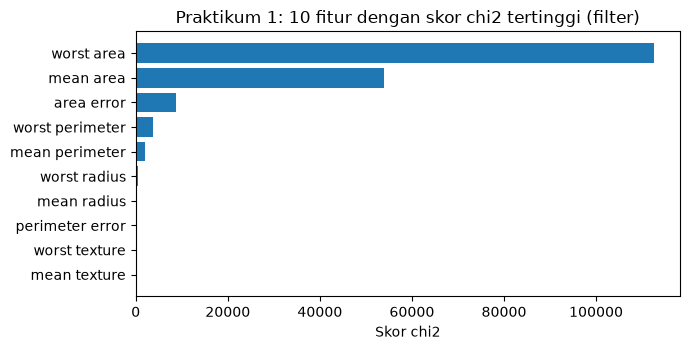

In [14]:
# Grafik Praktikum 1: skor chi2 untuk 10 fitur teratas (metode filter)
skor = skb.scores_
top10 = np.argsort(skor)[-10:][::-1]
plt.figure(figsize=(7, 3.6))
plt.barh([nama_fitur[i] for i in top10], skor[top10])
plt.xlabel("Skor chi2")
plt.title("Praktikum 1: 10 fitur dengan skor chi2 tertinggi (filter)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Penjelasan grafiknya:** metode filter menilai tiap fitur secara individual lewat skor chi2. Fitur-fitur `worst ...` (nilai terburuk tiap pengukuran sel) mendominasi peringkat teratas, masuk akal karena sel kanker ganas cenderung punya nilai ekstrem. Kelemahan filter yang terlihat di sini: fitur terpilih saling berkorelasi (banyak varian pengukuran yang sama), sedangkan wrapper/embedded memilih kombinasi yang saling melengkapi di dalam model.

**Penjelasan outputnya:**

1. Ketiga metode **gak milih himpunan yang identik**. Dari 18 fitur yang dipilih minimal satu metode, cuma **2** yang disepakati ketiganya: `mean radius` dan `worst radius`. Ini wajar: filter menilai tiap fitur *sendiri-sendiri* jadi cenderung milih fitur-fitur yang saling berkorelasi (banyak varian "worst ..." dan "mean ..."), sedangkan wrapper dan embedded mempertimbangkan **kontribusi fitur dalam konteks model**. RFE malah banyak milih fitur "*... error*" dan "*worst ...*" yang saling melengkapi di dalam model.
2. **Filter (chi2)** tercepat: cuma ngitung statistik sekali. **Wrapper (RFE)** paling lambat: ngelatih LogisticRegression berulang kali sambil buang fitur terlemah. **Embedded (L1)** cuma butuh satu kali training dan otomatis nentuin jumlah fitur (di sini 9 fitur, bukan genap 10).
3. **Kesimpulan:** gak ada metode yang "selalu bener". Filter cocok buat penyaringan awal yang cepet di data berdimensi besar; wrapper buat akurasi maksimal kalo komputasi bukan masalah; embedded sebagai jalan tengah yang elegan: seleksi terjadi sebagai efek samping training. Di praktiknya ketiganya sering **dikombinasikan** (filter dulu buat buang yang jelas-jelas noise, terus wrapper/embedded).

### Praktikum 2 - Membangun Pipeline Lengkap (Dataset Titanic) (Modul Bab 4)

Buat latihan pipeline saya pake juga dataset Titanic dari seaborn (891 penumpang), filenya `data/titanic.csv`. Ini contoh klasik data campuran: numerik (`age`, `fare`, `sibsp`, `parch`) + kategorikal (`sex`, `embarked`, `class`) dengan target klasifikasi `survived`. Pipeline: `ColumnTransformer` (numerik jadi median + scaler; kategorikal jadi most_frequent + one-hot) + `LogisticRegression`, dievaluasi pake **akurasi** di data uji.

In [15]:
# Import tambahan untuk latihan pipeline Titanic
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Dataset Titanic dibaca dari file CSV lokal (data/titanic.csv) - bisa dipakai offline
df_t = pd.read_csv('data/titanic.csv')
print("Dataset Titanic berhasil dimuat:", df_t.shape)
fitur_num_t = ['age', 'fare', 'sibsp', 'parch']
fitur_cat_t = ['sex', 'embarked', 'class']
X_t = df_t[fitur_num_t + fitur_cat_t]
y_t = df_t['survived']

print("\nMissing value per kolom:", X_t.isna().sum().to_dict())

Xtr, Xte, ytr, yte = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

pipe_titanic = Pipeline(steps=[
    ('preprocessing', ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())]), fitur_num_t),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(
                              handle_unknown='ignore'))]), fitur_cat_t),
    ])),
    ('model', LogisticRegression(max_iter=1000)),
])
pipe_titanic.fit(Xtr, ytr)
akurasi = accuracy_score(yte, pipe_titanic.predict(Xte))
print(f"\nAkurasi pada data uji: {akurasi:.4f}")
print("Prediksi 1 penumpang baru:", pipe_titanic.predict(Xte.iloc[[0]])[0],
      "(aktual:", yte.iloc[0], ")")

Dataset Titanic berhasil dimuat: (891, 15)

Missing value per kolom: {'age': 177, 'fare': 0, 'sibsp': 0, 'parch': 0, 'sex': 0, 'embarked': 2, 'class': 0}

Akurasi pada data uji: 0.7989
Prediksi 1 penumpang baru: 0 (aktual: 1 )


<Figure size 420x360 with 0 Axes>

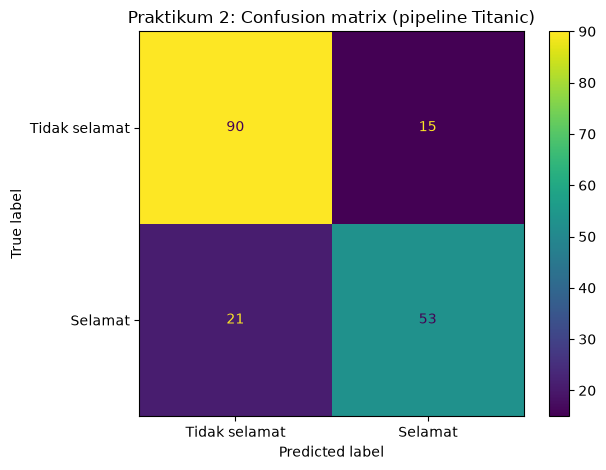

In [16]:
# Grafik Praktikum 2: confusion matrix pipeline Titanic di data uji
from sklearn.metrics import ConfusionMatrixDisplay
plt.figure(figsize=(4.2, 3.6))
ConfusionMatrixDisplay.from_estimator(pipe_titanic, Xte, yte,
                                      display_labels=["Tidak selamat", "Selamat"])
plt.title("Praktikum 2: Confusion matrix (pipeline Titanic)")
plt.tight_layout()
plt.show()

**Penjelasan grafiknya:** confusion matrix menunjukkan di mana model paling sering salah. Pola umumnya: model cukup baik mengenali penumpang yang tidak selamat, tapi sebagian penumpang yang selamat diprediksi tidak selamat. Ini wajar untuk model linear sederhana tanpa feature engineering lanjutan, dan alasannya akurasi 0,80 bukan 1,00.

**Penjelasan outputnya:**

1. Dataset Titanic berhasil dimuat (891 baris, 15 kolom) dari file lokal `data/titanic.csv`.
2. Missing value kedeteksi di `age` (sekitar 177) dan `embarked` (2). Keduanya ditangani otomatis di dalam pipeline (median buat numerik, modus buat kategorikal), tanpa satu baris pun kode pembersihan manual di luar pipeline.
3. Akurasi **0,7989** di data uji: wajar buat model linear sederhana tanpa *feature engineering* lanjutan, dan konsisten sama benchmark umum dataset Titanic.
4. Prediksi satu baris data mentah langsung jalan tanpa preprocessing manual. Sekali lagi nunjukin keunggulan pipeline: data baru cukup dilempar ke `pipe.predict()`, preprocessing yang tepat (termasuk penanganan NaN dan kategori gak dikenal via `handle_unknown='ignore'`) udah "terkunci" di dalamnya. Catatan jujur: prediksi contoh baris itu 0 padahal aktualnya 1. Pengingat kalo akurasi 80% artinya sekitar 1 dari 5 prediksi meleset.

## Kesimpulan Bab 4

1. **Feature construction** bikin pola implisit jadi eksplisit. Di dataset sintetis properti, fitur `rasio_kamar_per_luas` ternyata **tidak** menaikkan R2 (tetap 0,987), karena RandomForest sudah menangkap interaksi itu sendiri. Pelajarannya: selalu verifikasi pakai metrik, jangan asal tambah fitur.
2. Tiga pendekatan **feature selection**: *filter* (cepet, statistik murni), *wrapper* (akurat, mahal), *embedded* (seleksi menyatu sama training). Milih himpunan fitur yang beda-beda; gak ada yang selalu terbaik, dan ketiganya sering dikombinasikan.
3. **ColumnTransformer + Pipeline** adalah cara idiomatis scikit-learn buat nangani data campuran: tiap tipe kolom dapet preprocessing yang tepat, semuanya di-fit *cuma* di data latih jadi **data leakage** kehindar.
4. Keuntungan terbesar Pipeline keliatan pas **deployment**: `pipeline.predict(data_mentah)` selalu nerapin preprocessing yang identik sama training. Percobaan mandiri saya ngebuktiin replikasi manual berisiko *silent error* (hasil salah tanpa pesan error), sedangkan pipeline ngilangin seluruh kelas bug itu.
5. Selalu ada **trade-off komputasi vs performa**: 200 pohon vs 50 pohon hasilnya **identik** (R2 0,987) tapi 200 pohon 3x lebih lambat (0,3 vs 0,1 detik). Pilih jumlah pohon sesuai anggaran komputasi, bukan sekadar "lebih gede lebih bagus".